# Gaussian Process Emulator for CMB

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel
from sklearn.base import clone

## Example from Scikit-learn
https://scikit-learn.org/stable/modules/gaussian_process.html

In [2]:
X = np.linspace(start=0, stop=10, num=1_000).reshape(-1, 1)
y1 = np.squeeze(X * np.sin(X))
y2 = np.squeeze(X * np.cos(X))
y = np.column_stack((y1, y2))

In [3]:
y.shape

(1000, 2)

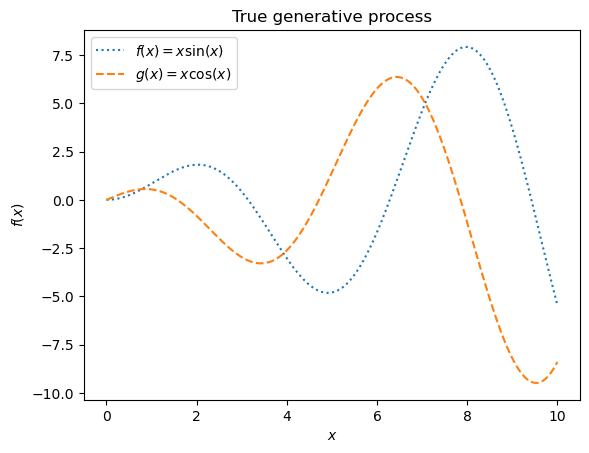

In [4]:
plt.plot(X, y1, label=r"$f(x) = x \sin(x)$", linestyle="dotted")
plt.plot(X, y2, label=r"$g(x) = x \cos(x)$", linestyle="--")
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("True generative process")

In [5]:
rng = np.random.RandomState(1)
training_indices = rng.choice(np.arange(1000), size=6, replace=False)
X_train, y_train = X[training_indices], y[training_indices]

In [6]:
y_train

array([[-4.74492726,  1.80056999],
       [ 7.73514288, -2.68588726],
       [-4.44491693, -0.84500632],
       [-1.90051689, -3.15556034],
       [ 1.5957965 , -1.82251583],
       [ 1.16380401, -9.22618706]])

In [7]:
kernel = 1 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9)
gaussian_process.fit(X_train, y_train)
gaussian_process.kernel_

5.98**2 * RBF(length_scale=1.7)

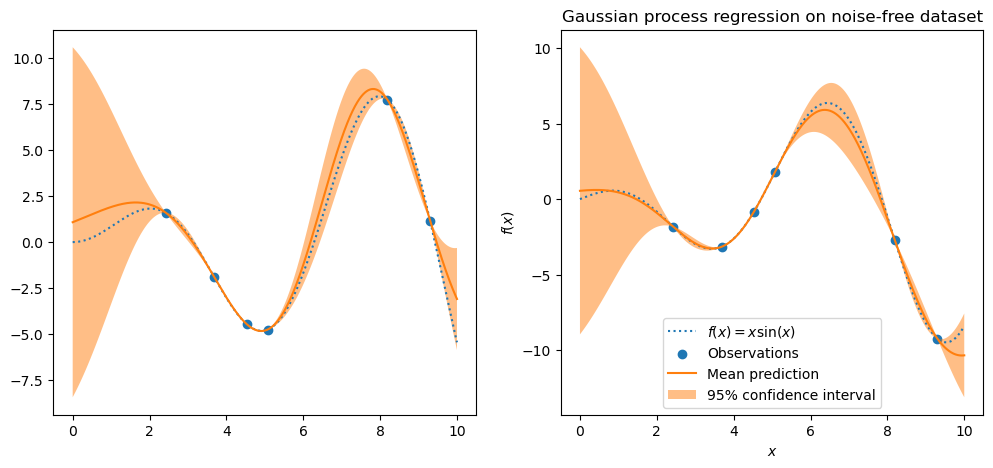

In [8]:
mean_prediction, std_prediction = gaussian_process.predict(X, return_std=True)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(X, y[:, 0], label=r"$f(x) = x \sin(x)$", linestyle="dotted")
axs[0].scatter(X_train, y_train[:, 0], label="Observations")
axs[0].plot(X, mean_prediction[:, 0], label="Mean prediction")
axs[0].fill_between(
    X.ravel(),
    mean_prediction[:, 0] - 1.96 * std_prediction[:, 0],
    mean_prediction[:, 0] + 1.96 * std_prediction[:, 0],
    alpha=0.5,
    label=r"95% confidence interval",
)

axs[1].plot(X, y[:, 1], label=r"$f(x) = x \sin(x)$", linestyle="dotted")
axs[1].scatter(X_train, y_train[:, 1], label="Observations")
axs[1].plot(X, mean_prediction[:, 1], label="Mean prediction")
axs[1].fill_between(
    X.ravel(),
    mean_prediction[:, 1] - 1.96 * std_prediction[:, 1],
    mean_prediction[:, 1] + 1.96 * std_prediction[:, 1],
    alpha=0.5,
    label=r"95% confidence interval",
)
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("Gaussian process regression on noise-free dataset")

## CMB Dataset

In [9]:
NUM_TRAIN_SAMPLES = 300
NUM_TEST_SAMPLES = 200
NUM_ELL = 2999

ell = np.arange(2, 3001)
factor = ell*(ell+1)/(2*np.pi)
train_cosmologies = np.loadtxt("../data/train_300/cosmologies.txt", max_rows=NUM_TRAIN_SAMPLES)
test_cosmologies = np.loadtxt("../data/test_200/cosmologies.txt", max_rows=NUM_TEST_SAMPLES)
train_cls = np.zeros((NUM_TRAIN_SAMPLES, NUM_ELL))
test_cls  = np.empty((NUM_TEST_SAMPLES, NUM_ELL))

for i in range(1, NUM_TRAIN_SAMPLES+1):
    cl_tt, cl_te, cl_ee = np.loadtxt(f"../data/train_300/cl_{i}.txt", unpack=True)
    train_cls[i-1] = cl_tt

for i in range(1, NUM_TEST_SAMPLES+1):
    cl_tt, cl_te, cl_ee = np.loadtxt(f"../data/test_200/cl_{i}.txt", unpack=True)
    test_cls[i-1] = cl_tt


/tmp/ipykernel_56392/1679661194.py:7: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=300`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  train_cosmologies = np.loadtxt("../data/train_300/cosmologies.txt", max_rows=NUM_TRAIN_SAMPLES)
/tmp/ipykernel_56392/1679661194.py:8: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=200`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If y

In [10]:
# Thinning training sample
# partial_indices = np.random.choice(np.arange(NUM_TRAIN_SAMPLES), size=1000, replace = False)
train_cosmologies_partial = train_cosmologies
train_cls_partial         = train_cls/factor
print(train_cosmologies_partial.shape)
print(train_cls_partial.shape)

(300, 6)
(300, 2999)


In [ ]:
As1e10 = np.exp(train_cosmologies_partial[:, 3])
for i, cl in enumerate(train_cls_partial):
    train_cls_partial[i]  = cl #here maybe divide by 1e10As?
# train_cosmologies_partial = np.delete(train_cosmologies_partial, 3, axis=1) # No need for As in inputs

# Take the log
train_logcls_partial = np.log(train_cls_partial)

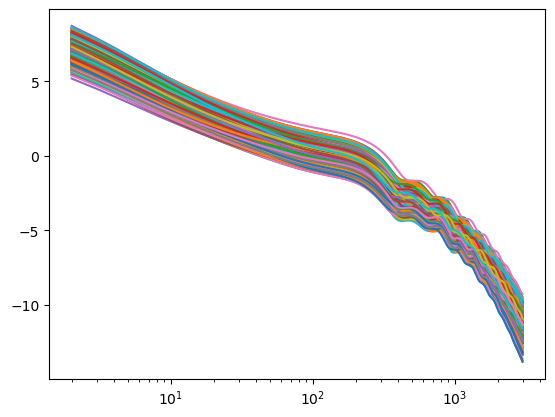

In [12]:
for logcl in train_logcls_partial:
    plt.semilogx(ell, logcl)

In [13]:
# Scalers for inputs and outputs
scaler_cosmo = StandardScaler()
scaler_cosmo.fit(train_cosmologies_partial)
scaler_logcls = StandardScaler()
scaler_logcls.fit(train_logcls_partial)

,copy,True
,with_mean,True
,with_std,True


In [14]:
# PCA
pca = PCA(n_components=30, svd_solver='randomized', iterated_power =3, random_state = 42)
train_pcs = pca.fit_transform(scaler_logcls.transform(train_logcls_partial))
scaler_pcs = StandardScaler().fit(train_pcs)

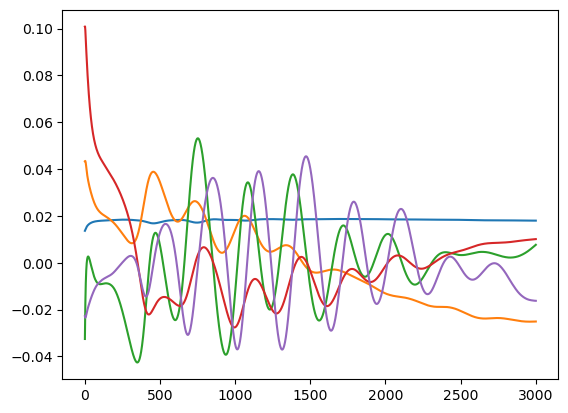

In [15]:
plt.plot(ell, pca.components_[0])
plt.plot(ell, pca.components_[1])
plt.plot(ell, pca.components_[2])
plt.plot(ell, pca.components_[3])
plt.plot(ell, pca.components_[4])

In [ ]:
X_train = scaler_cosmo.transform(train_cosmologies_partial)
y_train = scaler_pcs.transform(train_pcs)

# fitting a quadratic to the cosmo params (try to capture correlation)
quadratic = PolynomialFeatures(
    degree = 2,
    include_bias = False,
)
X_quad = quadratic.fit_transform(X_train) #transform the training cosmologies to the quadratic coefficients

print("original input shape:",X_train.shape)
print("quad input shape:", X_quad.shape)

n_components = y_train.shape[1]
n_parameters = X_train.shape[1]

trend_models = [] #will hold the quadratic trend for each PCA component
training_resid = np.empty_like(y_train) #residuals for the PCA trend 

for component in range(n_components):
    trend = make_pipeline(
        StandardScaler(),
        Ridge(alpha = 1e-3),
    )

    trend.fit(
        X_quad,
        y_train[:,component],
    )   # fits 27 quadratic components for each PCA coefficient
    trend_pred = trend.predict(X_quad) # predict the PCA coefficient from the 27 quadratic components

    training_resid[:, component] = (
        y_train[:,component] - trend_pred
    )   #residual between actual PCA and predicted PCA

    trend_models.append(trend)

base_kernel = ConstantKernel(constant_value=1, constant_value_bounds=(1e-3, 1e3)) * Matern(length_scale=np.ones(n_parameters), length_scale_bounds=(1e-2, 1e3), nu=2.5)
resid_gp_models = [] #will hold the residual gp_models

for component in range(n_components):
    #emulate the residuals from the quadratic fit using the og cosmologies. Each PCA has 6 diff length scales
    gp = GaussianProcessRegressor(
        kernel = clone(base_kernel),
        alpha = 1e-6,
        normalize_y = False,
        n_restarts_optimizer =3 ,
        random_state = 42+component,
    )
    gp.fit(
        X_train,
        training_resid[:,component],
    )
    resid_gp_models.append(gp)

original input shape: (300, 6)
quad input shape: (300, 27)


/home/baylihayes/miniconda3/envs/oasis/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/baylihayes/miniconda3/envs/oasis/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/baylihayes/miniconda3/envs/oasis/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/hom

In [45]:
training_resid[0]

array([-0.00180405, -0.06954156, -0.40541772, -0.0073975 ,  0.0793229 ,
       -1.60985507,  0.75151953,  0.51845786, -0.41679827, -0.07735646,
        0.54791679,  0.2143399 , -0.99947567,  0.05572207,  0.22160247,
        0.49088742,  0.55719443, -0.66195297, -0.45428573,  0.06098823,
       -1.28633868,  1.05218046,  0.70566691, -0.04374112, -0.72267075,
       -0.43314071, -0.25780739, -0.47416219,  0.86775856,  0.66172568])

In [47]:
# Convert the true test D_l spectra to C_l
test_cls_for_pca = test_cls / factor

# Apply exactly the same output transformations used in training
test_logcls = np.log(test_cls_for_pca)
test_logcls_scaled = scaler_logcls.transform(test_logcls)
test_pcs = pca.transform(test_logcls_scaled)
test_pcs_scaled = scaler_pcs.transform(test_pcs)

print(test_pcs_scaled.shape)

(200, 30)


In [ ]:
def predict(x):
    x_input = np.asarray(x)[None,:]
    x_scaled = scaler_cosmo.transform(x_input) #scale the cosmologies

    x_quad = quadratic.transform(x_scaled)  #transform data into quadratic components

    pred_pcs_scaled = np.empty((1,n_components))

    for component in range(n_components):
        trend_pred = trend_models[component].predict(x_quad) #predicting the quadratic trend
        resid_pred = resid_gp_models[component].predict(x_scaled) #predicting the residuals
        pred_pcs_scaled[:, component] = trend_pred + resid_pred #adding the full prediction

    pred_pcs = scaler_pcs.inverse_transform(pred_pcs_scaled) #transform PCA coeffs back to unscaled

    pred_logcls_scaled = pca.inverse_transform(pred_pcs) # changing back from PCA coefficients to log Cl

    pred_logcls = scaler_logcls.inverse_transform(pred_logcls_scaled) #unscaling log cl

    pred_cl = np.exp(pred_logcls)[0]

    pred_dl = pred_cl * factor
    return pred_dl

Median signed error: -0.0008118358964333439 %
Median absolute error: 0.13051487994908656 %
95th percentile absolute error: 0.7174039731906469 %
Maximum absolute error: 8.3063307077679 %


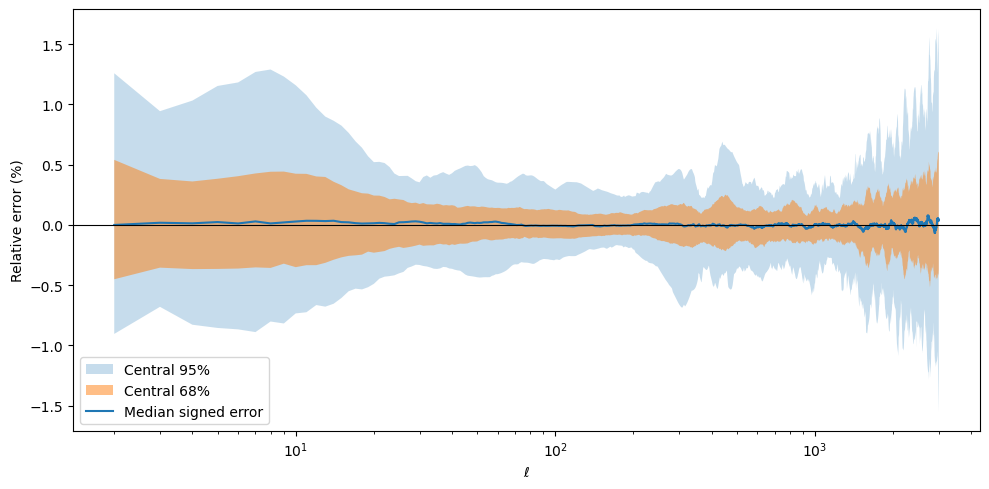

In [51]:
from datetime import datetime
from pathlib import Path

errors = np.empty((NUM_TEST_SAMPLES, NUM_ELL))
for i in range(NUM_TEST_SAMPLES):
    truth = test_cls[i]
    pred = predict(test_cosmologies[i])
    errors[i] = 100 * (pred - truth) / truth  # percent error
errors = np.array(errors)
absolute_errors = np.abs(errors)
print("Median signed error:", np.median(errors), "%")
print("Median absolute error:", np.median(absolute_errors), "%")
print("95th percentile absolute error:", np.percentile(absolute_errors, 95), "%")
print("Maximum absolute error:", np.max(absolute_errors), "%")

median = np.median(errors, axis=0)
p025, p975 = np.percentile(errors, [2.5, 97.5], axis=0)
p16, p84 = np.percentile(errors, [16, 84], axis=0)
worst = np.max(absolute_errors, axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(ell, p025, p975, alpha=0.25, label="Central 95%")
ax.fill_between(ell, p16, p84, alpha=0.50, label="Central 68%")
ax.plot(ell, median, label="Median signed error")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xscale("log")
ax.set_xlabel(r"$\ell$")
ax.set_ylabel("Relative error (%)")
ax.legend()
fig.tight_layout()

# results_dir = Path("../results")
# results_dir.mkdir(parents=True, exist_ok=True)
# run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
# run_name = f"train300_test200_{run_id}"

# np.savez_compressed(
#     results_dir / f"{run_name}.npz",
#     ell=ell,
#     errors=errors,
#     absolute_errors=absolute_errors,
#     median=median,
#     p025=p025,
#     p975=p975,
#     p16=p16,
#     p84=p84,
#     worst=worst,
#     test_cosmologies=test_cosmologies,
#     test_cls=test_cls,
# )
# plot_path = results_dir / f"{run_name}.png"
# fig.savefig(plot_path, dpi=200, bbox_inches="tight")
# print(f"Saved results to {results_dir / f'{run_name}.npz'}")
# print(f"Saved plot to {plot_path}")

In [52]:
case_mae = np.median(absolute_errors, axis=1)

print("Worst test case:", np.argmax(case_mae))
print("Worst case median absolute error:", np.max(case_mae), "%")

Worst test case: 89
Worst case median absolute error: 0.9154426404541179 %


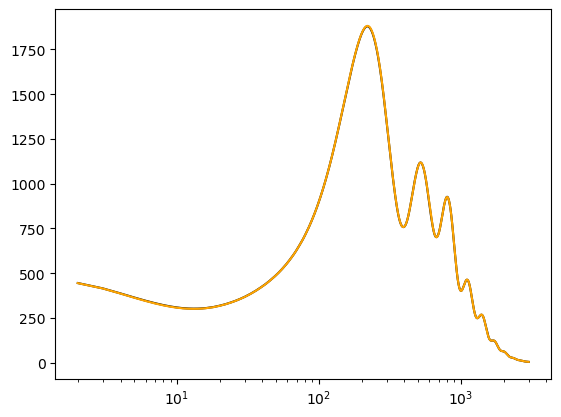

In [53]:
i = 80
truth = test_cls[i]
pred = predict(test_cosmologies[i])
plt.plot(ell, truth, color="black")
plt.semilogx(ell, pred, color="orange")

In [46]:
parameter_names = np.array([
    "h",
    "omch2",
    "ombh2",
    "ln(10^10As)",
    "ns",
    "tau",
])

def predict_scaled_pcs(cosmologies):
    """
    Predict all 30 PCA coeffs. 
    """

    x_scaled = scaler_cosmo.transform(cosmologies)
    x_quad = quadratic.transform(x_scaled)

    predictions = np.empty(
        (len(cosmologies), n_components)
    )

    for component in range(n_components):
        trend_prediction = trend_models[component].predict(x_quad)
        resid_prediction = resid_gp_models[component].predict(x_scaled)
        predictions[:, component] = (trend_prediction + resid_prediction)

    return predictions

In [48]:
predicted_pcs_scaled = predict_scaled_pcs(test_cosmologies)

pc_rmse = np.sqrt(
    np.mean(
        (predicted_pcs_scaled - test_pcs_scaled)**2,
        axis=0,
    )
)

pc_mae = np.mean(
    np.abs(predicted_pcs_scaled - test_pcs_scaled),
    axis=0,
)

for component in range(n_components):
    print(
        f"PC {component + 1:2d}: "
        f"RMSE={pc_rmse[component]:.4f}, "
        f"MAE={pc_mae[component]:.4f}"
    )

PC  1: RMSE=0.0012, MAE=0.0007
PC  2: RMSE=0.0050, MAE=0.0030
PC  3: RMSE=0.0097, MAE=0.0062
PC  4: RMSE=0.0069, MAE=0.0047
PC  5: RMSE=0.0163, MAE=0.0115
PC  6: RMSE=0.0494, MAE=0.0335
PC  7: RMSE=0.0747, MAE=0.0493
PC  8: RMSE=0.1032, MAE=0.0604
PC  9: RMSE=0.0469, MAE=0.0352
PC 10: RMSE=0.0709, MAE=0.0463
PC 11: RMSE=0.1190, MAE=0.0857
PC 12: RMSE=0.1050, MAE=0.0704
PC 13: RMSE=0.3485, MAE=0.2220
PC 14: RMSE=0.0632, MAE=0.0349
PC 15: RMSE=0.3082, MAE=0.1809
PC 16: RMSE=0.4158, MAE=0.2443
PC 17: RMSE=0.4493, MAE=0.1765
PC 18: RMSE=0.4000, MAE=0.2025
PC 19: RMSE=0.3557, MAE=0.2454
PC 20: RMSE=0.3400, MAE=0.2053
PC 21: RMSE=0.7652, MAE=0.3382
PC 22: RMSE=0.3835, MAE=0.2820
PC 23: RMSE=0.2986, MAE=0.1882
PC 24: RMSE=0.5452, MAE=0.3199
PC 25: RMSE=0.6797, MAE=0.4350
PC 26: RMSE=0.4177, MAE=0.2584
PC 27: RMSE=0.5035, MAE=0.3135
PC 28: RMSE=0.7141, MAE=0.4583
PC 29: RMSE=0.7496, MAE=0.4479
PC 30: RMSE=0.6208, MAE=0.3854


In [49]:
# for component in range(n_components):
#     original_std = np.std(y_train[:,component])
#     residual_std = np.std(
#         training_resid[:, component]
#     )

#     fraction_remaining = residual_std / original_std

#     print(
#         f"PC {component + 1:02d}:"
#         f"residual / original std ="
#         f"{fraction_remaining:.3f}"
#     )

In [54]:
rng = np.random.default_rng(42)


baseline_prediction = predict_scaled_pcs(test_cosmologies)

baseline_mse = np.mean(
    (baseline_prediction - test_pcs_scaled)**2,
    axis=0,
)

importance = np.empty(
    (n_components, len(parameter_names))
)

n_repeats = 20

for parameter_index in range(len(parameter_names)):
    shuffled_mse = np.empty((n_repeats, n_components))

    for repeat in range(n_repeats):
        shuffled_cosmologies = test_cosmologies.copy()

        shuffled_cosmologies[:, parameter_index] = rng.permutation(
            shuffled_cosmologies[:, parameter_index]
        )

        shuffled_prediction = predict_scaled_pcs(
            shuffled_cosmologies
        )

        shuffled_mse[repeat] = np.mean(
            (shuffled_prediction - test_pcs_scaled)**2,
            axis=0,
        )

    importance[:, parameter_index] = (
        np.mean(shuffled_mse, axis=0) - baseline_mse
    )

In [55]:
gp_length_scales = np.empty(
    (n_components, len(parameter_names))
)

for component, gp in enumerate(resid_gp_models):
    fitted_kernel = gp.kernel_

    # ConstantKernel * Matern
    gp_length_scales[component] = (
        fitted_kernel.k2.length_scale
    )

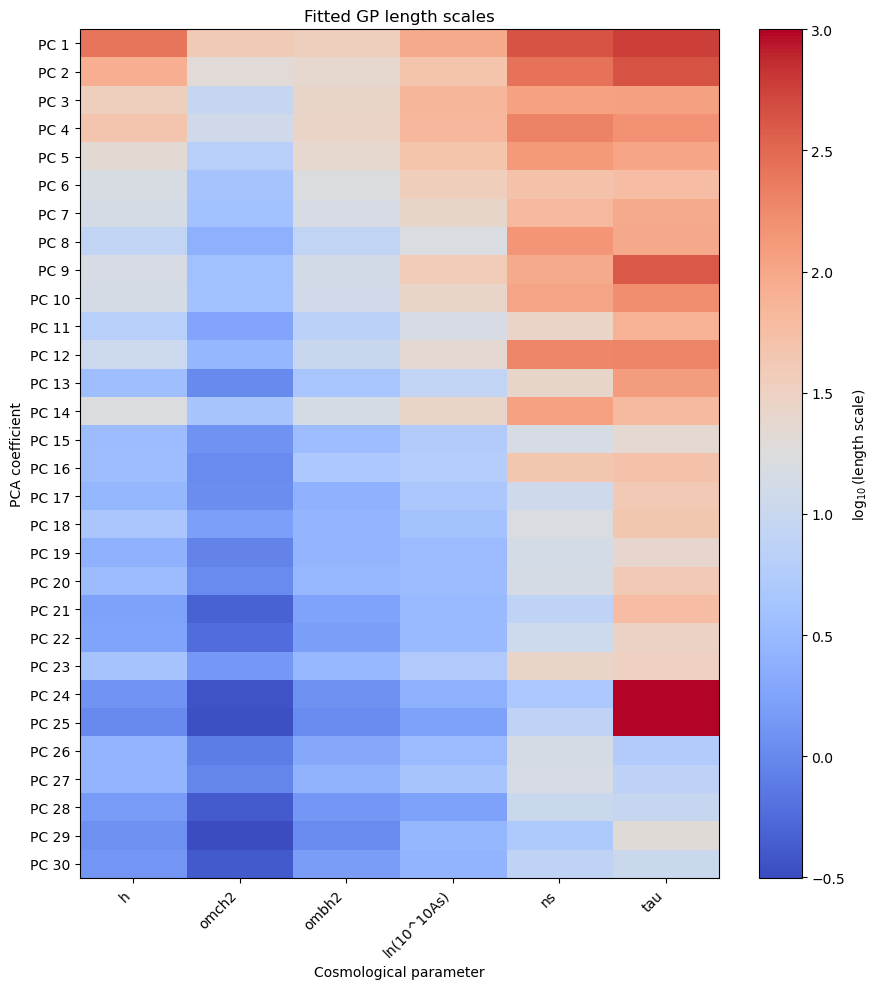

In [56]:
fig, ax = plt.subplots(figsize=(9, 10))

image = ax.imshow(
    np.log10(gp_length_scales),
    aspect="auto",
    cmap="coolwarm",
)

ax.set_xticks(np.arange(len(parameter_names)))
ax.set_xticklabels(parameter_names, rotation=45, ha="right")

ax.set_yticks(np.arange(n_components))
ax.set_yticklabels(
    [f"PC {i + 1}" for i in range(n_components)]
)

ax.set_xlabel("Cosmological parameter")
ax.set_ylabel("PCA coefficient")
ax.set_title("Fitted GP length scales")

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label(r"$\log_{10}$(length scale)")

fig.tight_layout()
plt.show()

In [57]:
component = 23  # PC 24
all_length_scales = []

for seed in range(10):
    gp_check = GaussianProcessRegressor(
        kernel=clone(base_kernel),
        alpha=1e-6,
        normalize_y=True,
        n_restarts_optimizer=3,
        random_state=seed,
    )

    gp_check.fit(
        X_train,
        training_resid[:, component],
    )

    all_length_scales.append(
        gp_check.kernel_.k2.length_scale
    )

all_length_scales = np.asarray(all_length_scales)

for index, name in enumerate(parameter_names):
    print(
        f"{name:14s}: "
        f"median={np.median(all_length_scales[:, index]):.3g}, "
        f"range=[{all_length_scales[:, index].min():.3g}, "
        f"{all_length_scales[:, index].max():.3g}]"
    )

/home/baylihayes/miniconda3/envs/oasis/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/baylihayes/miniconda3/envs/oasis/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/baylihayes/miniconda3/envs/oasis/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/bayl

h             : median=1.29, range=[1.29, 1.29]
omch2         : median=0.361, range=[0.361, 0.361]
ombh2         : median=1.15, range=[1.15, 1.15]
ln(10^10As)   : median=2.47, range=[2.47, 2.47]
ns            : median=4.87, range=[4.87, 4.87]
tau           : median=1e+03, range=[1e+03, 1e+03]


/home/baylihayes/miniconda3/envs/oasis/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [58]:
test_kernel = (
    ConstantKernel(
        constant_value=1,
        constant_value_bounds=(1e-3, 1e3),
    )
    * Matern(
        length_scale=np.ones(n_parameters),
        length_scale_bounds=(1e-2, 1e6),
        nu=2.5,
    )
)

gp_check = GaussianProcessRegressor(
    kernel=test_kernel,
    alpha=1e-6,
    normalize_y=True,
    n_restarts_optimizer=5,
    random_state=42,
)

component = 23  # PC 24, since Python starts at zero

gp_check.fit(
    X_train,
    training_resid[:, component],
)

print(gp_check.kernel_)
print(gp_check.kernel_.k2.length_scale)

1.41**2 * Matern(length_scale=[1.29, 0.361, 1.15, 2.47, 4.87, 1.22e+04], nu=2.5)
[1.29370856e+00 3.61125457e-01 1.15401010e+00 2.47016469e+00
 4.87206369e+00 1.21824496e+04]


In [59]:
component = 23

x_base = scaler_cosmo.transform(test_cosmologies)
x_base_quad = quadratic.transform(x_base)

base_trend = trend_models[component].predict(x_base_quad)
base_residual = resid_gp_models[component].predict(x_base)

trend_sensitivity = []
residual_sensitivity = []

rng = np.random.default_rng(42)

for parameter_index in range(len(parameter_names)):
    shuffled = test_cosmologies.copy()

    shuffled[:, parameter_index] = rng.permutation(
        shuffled[:, parameter_index]
    )

    x_shuffled = scaler_cosmo.transform(shuffled)
    x_shuffled_quad = quadratic.transform(x_shuffled)

    shuffled_trend = trend_models[component].predict(
        x_shuffled_quad
    )
    shuffled_residual = resid_gp_models[component].predict(
        x_shuffled
    )

    trend_sensitivity.append(
        np.sqrt(np.mean(
            (shuffled_trend - base_trend)**2
        ))
    )

    residual_sensitivity.append(
        np.sqrt(np.mean(
            (shuffled_residual - base_residual)**2
        ))
    )

for name, trend_effect, residual_effect in zip(
    parameter_names,
    trend_sensitivity,
    residual_sensitivity,
):
    print(
        f"{name:14s}: "
        f"trend effect={trend_effect:.5f}, "
        f"GP residual effect={residual_effect:.5f}")

h             : trend effect=0.22499, GP residual effect=0.76080
omch2         : trend effect=0.61007, GP residual effect=0.92742
ombh2         : trend effect=0.50812, GP residual effect=0.68992
ln(10^10As)   : trend effect=0.27757, GP residual effect=0.43586
ns            : trend effect=0.21715, GP residual effect=0.22801
tau           : trend effect=0.80569, GP residual effect=0.00001
